# Hybrid AQI Prediction Model: SARIMA + LSTM + SHAP
---
## Architecture
```
[Raw Data] -> [Preprocessing] -> [SARIMA] -> [Feature Fusion] -> [LSTM] -> [SHAP] -> [Final Prediction + Explanation]
```

This notebook replaces the XGBoost stage with an LSTM-based stage while keeping the SARIMA + fusion strategy.

## 1. Imports and Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import shap

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print('Libraries loaded.')

Libraries loaded.


## 2. Data Loading and Exploration

In [2]:
# Supports either Dataset.csv or city_day.csv
data_path = 'Dataset_filtered.csv'
df_raw = pd.read_csv(data_path)

rename_map = {'City': 'city', 'Date': 'date'}
df_raw = df_raw.rename(columns=rename_map)
if 'date' not in df_raw.columns:
    raise ValueError('Expected a Date/date column in the dataset.')

df_raw['date'] = pd.to_datetime(df_raw['date'])

print(f'Dataset shape: {df_raw.shape}')
print(f"Date range: {df_raw['date'].min()} to {df_raw['date'].max()}")
if 'city' in df_raw.columns:
    print(f"City count: {df_raw['city'].nunique()}")
df_raw.head()

Dataset shape: (11721, 16)
Date range: 2015-01-01 00:00:00 to 2020-07-01 00:00:00
City count: 6


,city,date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Bengaluru,2015-01-01,NaN,NaN,3.26,17.33,10.88,20.36,0.33,3.54,10.73,0.56,4.64,NaN,NaN,NaN
1,Bengaluru,2015-01-02,NaN,NaN,6.05,19.73,14.14,23.74,1.35,3.97,22.77,0.65,5.31,NaN,NaN,NaN
2,Bengaluru,2015-01-03,NaN,NaN,11.91,19.88,20.72,4.32,17.40,13.61,12.03,0.53,19.25,NaN,NaN,NaN
3,Bengaluru,2015-01-04,NaN,NaN,7.45,21.61,16.88,0.87,5.05,6.52,17.70,0.55,7.47,NaN,NaN,NaN
4,Bengaluru,2015-01-05,NaN,NaN,9.52,22.17,21.76,31.38,1.83,4.71,12.72,0.40,4.36,NaN,NaN,NaN


Modeling city: Delhi (non-null AQI rows: 1999)
Records before preprocessing: 2009


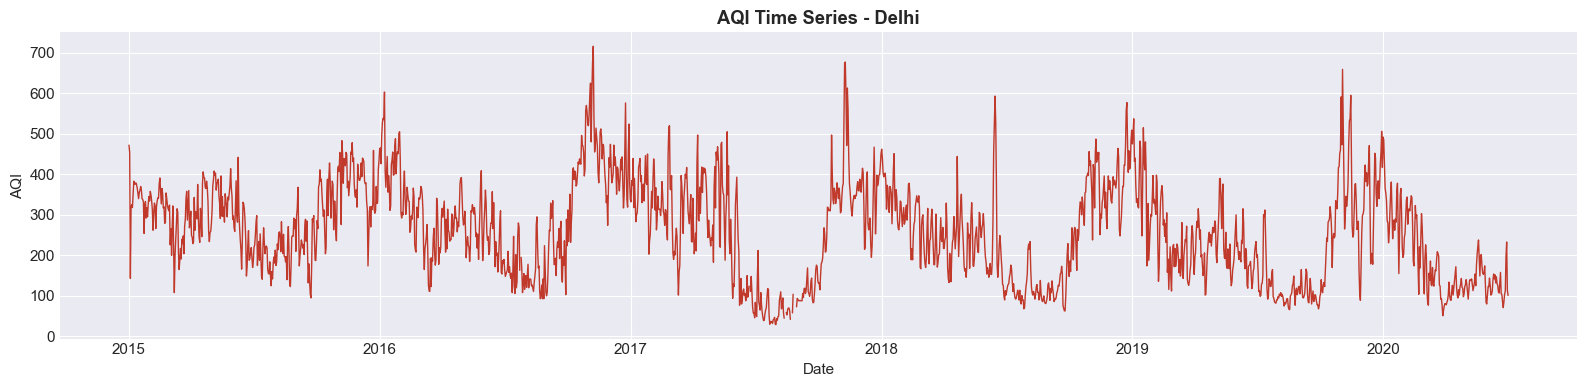

In [3]:
TARGET = 'AQI'

if TARGET not in df_raw.columns:
    raise ValueError("Target column 'AQI' not found in dataset.")

if 'city' in df_raw.columns:
    # Choose city with the most usable AQI records, not just most rows.
    city_valid_counts = (
        df_raw.groupby('city')[TARGET]
        .apply(lambda s: s.notna().sum())
        .sort_values(ascending=False)
    )

    if city_valid_counts.empty or city_valid_counts.iloc[0] == 0:
        raise ValueError('No city has non-null AQI values in this dataset.')

    CITY = city_valid_counts.index[0]
    df = df_raw[df_raw['city'] == CITY].copy()
    print(f'Modeling city: {CITY} (non-null AQI rows: {city_valid_counts.iloc[0]})')
else:
    CITY = 'SingleCityDataset'
    df = df_raw.copy()

df = df.sort_values('date').set_index('date')
print(f'Records before preprocessing: {len(df)}')

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df.index, df[TARGET], color='#c0392b', linewidth=1.0)
ax.set_title(f'AQI Time Series - {CITY}', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('AQI')
plt.tight_layout()
plt.show()

## 3. Preprocessing and Feature Engineering

In [4]:
POLLUTANTS = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3']
WEATHER = ['t2m', 'd2m', 'sp', 'blh', 'u10', 'v10']

keep_cols = [c for c in (POLLUTANTS + WEATHER + [TARGET]) if c in df.columns]
if TARGET not in keep_cols:
    raise ValueError("'AQI' is not available after column filtering.")

df = df[keep_cols].copy()
print(f'Initial columns: {list(df.columns)}')

# Drop feature columns that are entirely missing to avoid wiping all rows later.
all_nan_cols = [c for c in df.columns if c != TARGET and df[c].isna().all()]
if all_nan_cols:
    print(f'Dropping all-NaN feature columns: {all_nan_cols}')
    df = df.drop(columns=all_nan_cols)

# Keep rows where target exists; then fill feature gaps.
df = df[df[TARGET].notna()].copy()
print(f'Rows with non-null AQI: {len(df)}')

if len(df) == 0:
    raise ValueError('No rows with non-null AQI found after filtering.')

print(f'Missing before fill: {df.isna().sum().sum()}')
df = df.ffill().bfill()
df = df.asfreq('D').ffill().bfill()

for lag in [1, 2, 3, 7, 14]:
    df[f'AQI_lag_{lag}'] = df[TARGET].shift(lag)

df['AQI_roll_7_mean'] = df[TARGET].shift(1).rolling(7).mean()
df['AQI_roll_7_std'] = df[TARGET].shift(1).rolling(7).std()
df['AQI_roll_30_mean'] = df[TARGET].shift(1).rolling(30).mean()

df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['day_of_year'] = df.index.dayofyear
df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)

# Drop only rows that became invalid due to lag/rolling windows.
df = df.dropna()
print(f'Final shape after engineering: {df.shape}')
df.head()

Initial columns: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'AQI']
Rows with non-null AQI: 1999
Missing before fill: 258
Final shape after engineering: (1979, 22)


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI,...,AQI_lag_3,AQI_lag_7,AQI_lag_14,AQI_roll_7_mean,AQI_roll_7_std,AQI_roll_30_mean,day_of_week,month,day_of_year,is_weekend
date,,,,,,,,,,,,,,,,,,,,,
2015-01-31,158.59,207.06,30.67,41.36,57.77,67.66,8.70,5.03,17.51,334.0,...,295.0,324.0,360.0,319.142857,19.437323,342.566667,5,1,31,1
2015-02-01,211.59,371.05,57.56,58.17,93.17,96.69,13.08,9.90,23.28,358.0,...,327.0,333.0,370.0,320.571429,20.206081,337.966667,6,2,32,1
2015-02-02,163.64,219.84,13.70,37.25,39.34,84.49,10.59,5.31,28.38,349.0,...,345.0,292.0,362.0,324.142857,24.518215,334.766667,0,2,33,0
2015-02-03,157.71,194.09,12.28,31.05,34.10,66.38,8.21,5.64,28.56,334.0,...,334.0,318.0,340.0,332.285714,21.320681,341.633333,1,2,34,0
2015-02-04,137.26,147.08,15.21,29.69,36.06,53.28,9.11,5.06,15.07,313.0,...,358.0,295.0,338.0,334.571429,20.370380,342.133333,2,2,35,0


## 4. SARIMA Modeling

In [5]:
# Robust train-test split with safeguards
n_rows = len(df)
print(f'Total rows available after preprocessing: {n_rows}')

if n_rows < 20:
    raise ValueError(
        f'Not enough rows after preprocessing ({n_rows}). '
        'Reduce aggressive feature dropping or use a larger dataset.'
    )

split_idx = max(1, int(n_rows * 0.8))
split_idx = min(split_idx, n_rows - 1)  # ensure non-empty train and test

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print(f'Split index: {split_idx}')
print(f'Train rows: {len(train_df)}, Test rows: {len(test_df)}')

train_target = train_df[TARGET].dropna()

if len(train_target) < 10:
    print('Skipping ADF test: training target has too few non-null observations.')
    adf_stat, adf_p = np.nan, np.nan
elif train_target.nunique() <= 1:
    print('Skipping ADF test: training target is constant.')
    adf_stat, adf_p = np.nan, np.nan
else:
    adf_stat, adf_p, *_ = adfuller(train_target, autolag='AIC')
    print(f'ADF Statistic: {adf_stat:.4f}')
    print(f'p-value: {adf_p:.6f}')

Total rows available after preprocessing: 1979
Split index: 1583
Train rows: 1583, Test rows: 396
ADF Statistic: -3.1657
p-value: 0.022058


In [6]:
SARIMA_ORDER = (1, 1, 1)
SEASONAL_ORDER = (1, 1, 1, 7)

train_target = train_df[TARGET].dropna()
test_target = test_df[TARGET].dropna()

if len(train_target) < 30:
    raise ValueError(
        f'Insufficient training points for SARIMA: {len(train_target)}. '
        'Need at least ~30 observations for stable fitting.'
    )
if train_target.nunique() <= 1:
    raise ValueError('Training AQI series is constant; SARIMA cannot be fit meaningfully.')

sarima_model = SARIMAX(
    train_target,
    order=SARIMA_ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False, maxiter=200)

sarima_pred_train = sarima_fit.fittedvalues
sarima_pred_test = sarima_fit.forecast(steps=len(test_df))
sarima_pred_test.index = test_df.index

sarima_mae = mean_absolute_error(test_df[TARGET], sarima_pred_test)
sarima_mse = mean_squared_error(test_df[TARGET], sarima_pred_test)
sarima_rmse = np.sqrt(sarima_mse)
sarima_mape = np.mean(np.abs((test_df[TARGET] - sarima_pred_test) / test_df[TARGET])) * 100
sarima_r2 = r2_score(test_df[TARGET], sarima_pred_test)

print('SARIMA test metrics')
print(f'MAE: {sarima_mae:.3f} | RMSE: {sarima_rmse:.3f} | MAPE: {sarima_mape:.2f}% | R2: {sarima_r2:.4f}')

SARIMA test metrics
MAE: 99.790 | RMSE: 116.289 | MAPE: 68.07% | R2: -0.0390


## 5. Feature Fusion for LSTM
Add SARIMA predictions as an extra feature for the hybrid LSTM model.

In [7]:
df['SARIMA_pred'] = np.nan
df.loc[train_df.index, 'SARIMA_pred'] = sarima_pred_train
df.loc[test_df.index, 'SARIMA_pred'] = sarima_pred_test.values
df['SARIMA_pred'] = df['SARIMA_pred'].bfill().ffill()

FEATURE_COLS = [c for c in df.columns if c != TARGET]
BASELINE_FEATURES = [c for c in FEATURE_COLS if c != 'SARIMA_pred']

print(f'Baseline LSTM features: {len(BASELINE_FEATURES)}')
print(f'Hybrid LSTM features: {len(FEATURE_COLS)}')

Baseline LSTM features: 21
Hybrid LSTM features: 22


## 6. LSTM Utilities

In [8]:
LOOKBACK = 14
EPOCHS = 300
BATCH_SIZE = 16

def create_sequences(X, y, lookback):
    X_seq, y_seq = [], []
    for i in range(lookback, len(X)):
        X_seq.append(X[i - lookback:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

def build_lstm_model(n_features):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(LOOKBACK, n_features)),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, mape, r2

In [9]:
def prepare_lstm_data(feature_list):
    X = df[feature_list].copy()
    y = df[TARGET].copy().values.reshape(-1, 1)

    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]
    y_train = y[:split_idx]
    y_test = y[split_idx:]

    x_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()

    X_train_scaled = x_scaler.fit_transform(X_train)
    X_test_scaled = x_scaler.transform(X_test)

    y_train_scaled = y_scaler.fit_transform(y_train)
    y_test_scaled = y_scaler.transform(y_test)

    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, LOOKBACK)
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, LOOKBACK)

    test_index_seq = X_test.index[LOOKBACK:]

    return {
        'X_train_seq': X_train_seq,
        'y_train_seq': y_train_seq,
        'X_test_seq': X_test_seq,
        'y_test_seq': y_test_seq,
        'test_index_seq': test_index_seq,
        'y_scaler': y_scaler
    }

es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

## 7. Standalone LSTM (Without SARIMA Feature)

In [10]:
base_data = prepare_lstm_data(BASELINE_FEATURES)

lstm_only_model = build_lstm_model(base_data['X_train_seq'].shape[2])
history_only = lstm_only_model.fit(
    base_data['X_train_seq'], base_data['y_train_seq'],
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es],
    verbose=0
)

lstm_only_pred_scaled = lstm_only_model.predict(base_data['X_test_seq'], verbose=0)
lstm_only_pred = base_data['y_scaler'].inverse_transform(lstm_only_pred_scaled).ravel()
lstm_only_true = base_data['y_scaler'].inverse_transform(base_data['y_test_seq']).ravel()

lstm_only_mae, lstm_only_mse, lstm_only_rmse, lstm_only_mape, lstm_only_r2 = regression_metrics(lstm_only_true, lstm_only_pred)

print('Standalone LSTM test metrics')
print(f'MAE: {lstm_only_mae:.3f} | RMSE: {lstm_only_rmse:.3f} | MAPE: {lstm_only_mape:.2f}% | R2: {lstm_only_r2:.4f}')

Standalone LSTM test metrics
MAE: 29.301 | RMSE: 39.516 | MAPE: 18.31% | R2: 0.8837


## 8. Hybrid LSTM (With SARIMA Feature)

In [11]:
hybrid_data = prepare_lstm_data(FEATURE_COLS)

hybrid_lstm_model = build_lstm_model(hybrid_data['X_train_seq'].shape[2])
history_hybrid = hybrid_lstm_model.fit(
    hybrid_data['X_train_seq'], hybrid_data['y_train_seq'],
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es],
    verbose=0
)

hybrid_pred_scaled = hybrid_lstm_model.predict(hybrid_data['X_test_seq'], verbose=0)
hybrid_pred = hybrid_data['y_scaler'].inverse_transform(hybrid_pred_scaled).ravel()
hybrid_true = hybrid_data['y_scaler'].inverse_transform(hybrid_data['y_test_seq']).ravel()

hybrid_mae, hybrid_mse, hybrid_rmse, hybrid_mape, hybrid_r2 = regression_metrics(hybrid_true, hybrid_pred)

print('Hybrid (SARIMA + LSTM) test metrics')
print(f'MAE: {hybrid_mae:.3f} | RMSE: {hybrid_rmse:.3f} | MAPE: {hybrid_mape:.2f}% | R2: {hybrid_r2:.4f}')

Hybrid (SARIMA + LSTM) test metrics
MAE: 57.668 | RMSE: 74.708 | MAPE: 37.60% | R2: 0.5842


## 9. Model Comparison

,MAE,MSE,RMSE,MAPE (%),R2
Model,,,,,
SARIMA,101.8985,13933.5618,118.0405,69.8274,-0.0379
LSTM (Standalone),29.3011,1561.5279,39.5162,18.3147,0.8837
Hybrid (SARIMA+LSTM),57.6684,5581.3474,74.7084,37.5985,0.5842


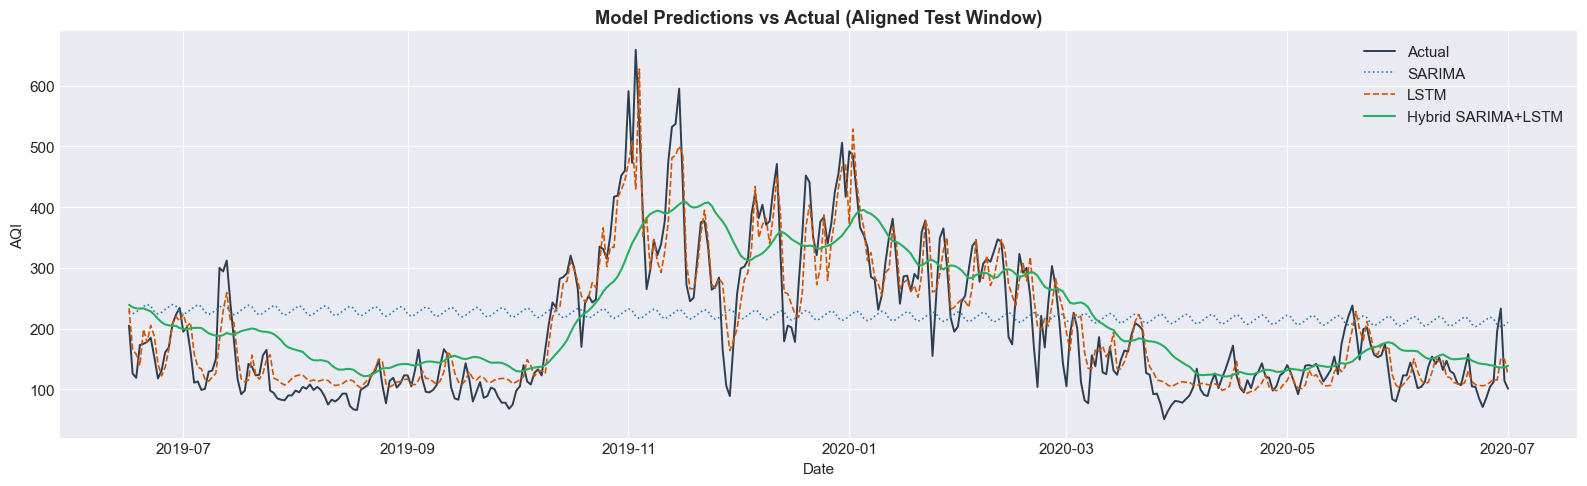

In [12]:
# Align SARIMA to sequence-based test window
aligned_test_index = hybrid_data['test_index_seq']
sarima_aligned = sarima_pred_test.loc[aligned_test_index].values
actual_aligned = test_df.loc[aligned_test_index, TARGET].values

sarima_seq_mae, sarima_seq_mse, sarima_seq_rmse, sarima_seq_mape, sarima_seq_r2 = regression_metrics(actual_aligned, sarima_aligned)

results = pd.DataFrame({
    'Model': ['SARIMA', 'LSTM (Standalone)', 'Hybrid (SARIMA+LSTM)'],
    'MAE': [sarima_seq_mae, lstm_only_mae, hybrid_mae],
    'MSE': [sarima_seq_mse, lstm_only_mse, hybrid_mse],
    'RMSE': [sarima_seq_rmse, lstm_only_rmse, hybrid_rmse],
    'MAPE (%)': [sarima_seq_mape, lstm_only_mape, hybrid_mape],
    'R2': [sarima_seq_r2, lstm_only_r2, hybrid_r2]
}).set_index('Model')

display(results.style.format('{:.4f}'))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(aligned_test_index, actual_aligned, label='Actual', color='#2c3e50', linewidth=1.4)
ax.plot(aligned_test_index, sarima_aligned, label='SARIMA', linestyle=':', linewidth=1.2, color='#2980b9')
ax.plot(aligned_test_index, lstm_only_pred, label='LSTM', linestyle='--', linewidth=1.2, color='#d35400')
ax.plot(aligned_test_index, hybrid_pred, label='Hybrid SARIMA+LSTM', linewidth=1.5, color='#27ae60')
ax.set_title('Model Predictions vs Actual (Aligned Test Window)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('AQI')
ax.legend()
plt.tight_layout()
plt.show()

## 10. SHAP for Hybrid LSTM
For sequence models, SHAP can be expensive. This cell runs on a sampled subset.

In [13]:
try:
    background_n = min(100, len(hybrid_data['X_train_seq']))
    explain_n = min(80, len(hybrid_data['X_test_seq']))

    background = hybrid_data['X_train_seq'][:background_n]
    explain_data = hybrid_data['X_test_seq'][:explain_n]

    explainer = shap.GradientExplainer(hybrid_lstm_model, background)
    shap_values = explainer.shap_values(explain_data)

    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    # Aggregate SHAP values across samples and timesteps for feature ranking
    mean_abs_importance = np.mean(np.abs(shap_values), axis=(0, 1))
    shap_imp = pd.DataFrame({
        'Feature': FEATURE_COLS,
        'MeanAbsSHAP': mean_abs_importance
    }).sort_values('MeanAbsSHAP', ascending=False)

    display(shap_imp.head(15))

    plt.figure(figsize=(10, 6))
    top_shap = shap_imp.head(12).sort_values('MeanAbsSHAP')
    plt.barh(top_shap['Feature'], top_shap['MeanAbsSHAP'], color='#16a085')
    plt.title('Hybrid LSTM SHAP Importance (Top Features)', fontweight='bold')
    plt.xlabel('Mean |SHAP|')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print('SHAP explanation skipped due to runtime/backend limitations.')
    print(f'Details: {e}')

SHAP explanation skipped due to runtime/backend limitations.
Details: Per-column arrays must each be 1-dimensional


## 11. Final Output

In [14]:
summary = pd.DataFrame({
    'Date': aligned_test_index[:10],
    'Actual_AQI': actual_aligned[:10],
    'SARIMA_Pred': sarima_aligned[:10],
    'LSTM_Pred': lstm_only_pred[:10],
    'Hybrid_Pred': hybrid_pred[:10]
}).round(2)
summary['Hybrid_Abs_Error'] = np.abs(summary['Actual_AQI'] - summary['Hybrid_Pred']).round(2)
display(summary)

print('Best model from this run:')
print(results.sort_values('MAE').head(1))

,Date,Actual_AQI,SARIMA_Pred,LSTM_Pred,Hybrid_Pred,Hybrid_Abs_Error
0,2019-06-16,205.0,228.60,233.500000,239.179993,34.18
1,2019-06-17,126.0,224.70,165.710007,235.289993,109.29
2,2019-06-18,119.0,227.25,157.779999,233.229996,114.23
3,2019-06-19,173.0,232.09,138.759995,232.889999,59.89
4,2019-06-20,175.0,236.31,198.949997,233.300003,58.30
5,2019-06-21,178.0,240.08,177.330002,230.789993,52.79
6,2019-06-22,185.0,237.18,205.300003,228.399994,43.40
7,2019-06-23,153.0,227.98,187.350006,222.940002,69.94
8,2019-06-24,118.0,224.15,142.339996,216.119995,98.12
9,2019-06-25,131.0,226.75,122.269997,210.580002,79.58


Best model from this run:
                         MAE          MSE       RMSE   MAPE (%)        R2
Model                                                                    
LSTM (Standalone)  29.301134  1561.527946  39.516173  18.314732  0.883678
